In [2]:
"""Setup for accessibility compliance analysis.

This cell:
- Imports required libraries
- Loads the audio/video ETL output into `av_data`
- Prepares the dataset for downstream accessibility summaries/visualizations
"""

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import warnings

# Keep notebook output cleaner by suppressing non-critical warnings
warnings.filterwarnings("ignore")

# Path configuration: adjust these if your ETL output location changes
base_path = Path("../etl-output")
audiovisual_path = base_path / "contentservice" / "audiovideoprocessed" / "data"

print("Loading audio/video data for accessibility analysis...")
av_files = glob.glob(str(audiovisual_path / "part-*.csv"))

if not av_files:
    raise FileNotFoundError(
        f"No audio/video CSV files found in {audiovisual_path}. "
        "Confirm that the ETL pipeline has produced output and the path is correct."
    )

# Combine all parts into a single DataFrame
av_data = pd.concat([pd.read_csv(f) for f in av_files], ignore_index=True)

print(f"Loaded {len(av_data):,} audio/video records for accessibility analysis")
print("Columns:", list(av_data.columns))


Loading audio/video data for accessibility analysis...
Loaded 35,831 audio/video records for accessibility analysis
Columns: ['content_id', 'revision_id', 'revision_number', 'type', 'source', 'revision_size', 'duration', 'required_transcoding', 'required_transcribing', 'last_modified']


ACCESSIBILITY COMPLIANCE SUMMARY

Transcription Status:
  Total multimedia content: 35,831
  Content requiring transcription: 1,676 (4.7%)
  Content with transcription/not required: 34,155 (95.3%)

By Media Type:
  Video:
    Total: 27,046
    Needs transcription: 1,357 (5.0%)
  Audio:
    Total: 8,785
    Needs transcription: 319 (3.6%)


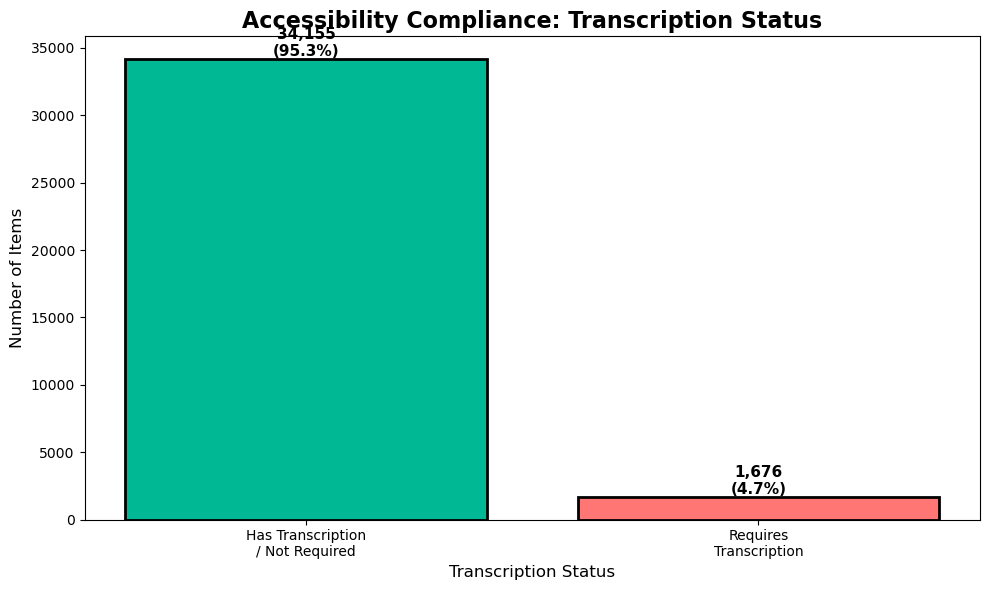

In [3]:
# Accessibility compliance summary for multimedia transcription
#
# This cell provides an at-a-glance view of how well the multimedia
# library complies with transcription-related accessibility requirements.
#
# It assumes that the following are already defined in this notebook:
#   - `av_data`: pandas DataFrame with one row per audio/video item
#   - `required_transcribing` column: boolean flag indicating whether
#       the item requires a transcript for accessibility compliance
#   - `type` column: media type, typically 'Audio' or 'Video'
#   - `pd`: pandas imported as `import pandas as pd`
#   - `plt`: matplotlib imported as `import matplotlib.pyplot as plt`

print("ACCESSIBILITY COMPLIANCE SUMMARY")
print("=" * 70)

# Guard clause: make the cell fail-safe if the expected column
# is missing (e.g., if the upstream ETL/schema changes).
if 'required_transcribing' in av_data.columns:
    # --- Overall transcription status -------------------------------------------------
    # Total number of multimedia items (denominator for all percentages)
    total_content = len(av_data)

    # `required_transcribing` is a boolean, so `.sum()` counts how many
    # items are flagged as needing a transcript.
    needs_transcription = av_data['required_transcribing'].sum()

    # Everything else is considered either already compliant or not
    # required to have transcription (e.g., silent clips, non-speech).
    has_transcription = total_content - needs_transcription

    print(f"\nTranscription Status:")
    print(f"  Total multimedia content: {total_content:,}")
    print(
        f"  Content requiring transcription: {needs_transcription:,} "
        f"({needs_transcription/total_content*100:.1f}%)"
    )
    print(
        f"  Content with transcription/not required: {has_transcription:,} "
        f"({has_transcription/total_content*100:.1f}%)"
    )

    # --- Breakdown by media type (e.g., Audio vs Video) ------------------------------
    # This loop highlights whether certain media types are less compliant
    # than others, which can inform where to focus remediation efforts.
    print(f"\nBy Media Type:")
    for media_type in av_data['type'].unique():
        # Subset to a single media type
        type_data = av_data[av_data['type'] == media_type]

        # Count how many items of this type require transcription
        type_needs = type_data['required_transcribing'].sum()
        type_total = len(type_data)

        print(f"  {media_type}:")
        print(f"    Total: {type_total:,}")
        print(
            f"    Needs transcription: {type_needs:,} "
            f"({type_needs/type_total*100:.1f}%)"
        )

    # --- Visualization: high-level compliance bar chart ------------------------------
    # Build a small DataFrame suitable for plotting a simple bar chart
    # showing compliant vs non-compliant counts.
    compliance_data = pd.DataFrame({
        'Status': ['Has Transcription\n/ Not Required', 'Requires\nTranscription'],
        'Count': [has_transcription, needs_transcription],
    })

    fig, ax = plt.subplots(figsize=(10, 6))

    # Choose contrasting colors so that compliant vs non-compliant
    # is visually obvious at a glance.
    colors_compliance = ['#00B894', '#FF7675']  # green for compliant, red for gap
    bars = ax.bar(
        compliance_data['Status'],
        compliance_data['Count'],
        color=colors_compliance,
        edgecolor='black',
        linewidth=2,
    )

    ax.set_title(
        'Accessibility Compliance: Transcription Status',
        fontsize=16,
        fontweight='bold',
    )
    ax.set_ylabel('Number of Items', fontsize=12)
    ax.set_xlabel('Transcription Status', fontsize=12)

    # Annotate each bar with its absolute count and percentage so
    # the chart is self-explanatory even without the surrounding text.
    for bar, count in zip(bars, compliance_data['Count']):
        height = bar.get_height()
        pct = count / total_content * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f'{count:,}\n({pct:.1f}%)',
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=11,
        )

    plt.tight_layout()
    plt.show()

else:
    # Fallback message when the expected data is not present; this
    # prevents hard errors and makes it clear what needs to be fixed.
    print("\nTranscription data not available in the dataset.")

print("\n" + "=" * 70)
